<a href="https://colab.research.google.com/github/nicolastibata/MINE_4210_ADL_202620/blob/main/assingments/assingment_1/MINE_4210_ADL_202620_T1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/logo.png?raw=true)


# **Taller 1: Clasificación multiclase con un MLP**

## **Integrantes: Grupo 8**
* Juan Esteban Álvarez García - 202212030
* Daniel Felipe Ortiz Vallejo - 202221234

### **Contexto y Objetivos**

La obesidad es un problema de salud pública creciente, asociado a enfermedades cardiovasculares, diabetes y otras condiciones crónicas. Identificar el nivel de riesgo de una persona a partir de sus hábitos, sin depender de mediciones clínicas directas como el peso o la estatura, puede ser útil cuando esta información no está disponible o se busca anticipar el riesgo antes de que se manifieste físicamente. En este taller deberán estimar el nivel de obesidad de una persona a partir de variables sociodemográficas y de estilo de vida, como alimentación, actividad física, consumo de alcohol y medio de transporte.

El objetivo de este Taller es construir un perceptrón multicapa (MLP) para esta tarea, siguiendo el proceso de machine learning. Se realizará una búsqueda de hiperparámetros sobre la arquitectura de la red, variando el número de capas ocultas y el número de neuronas por capa.


| Hiperparámetro | Valores para explorar |
|-|-|
| Número de capas ocultas | 1, 2 o 3. |
| Neuronas por capa oculta | 16, 32 o 64 (mismo valor en todas las capas ocultas de una misma arquitectura). |
| Callback obligatorio | Early stopping, monitoreando val_loss, con un valor de patience justificado. |


### **Entregable**

Notebook (.ipynb) con todas las celdas ejecutadas y con todas las indicaciones anteriormente estipuladas en la sección de laboratorios en **Bloque Neón**.



### **0. Configuración inicial e importaciones**

En esta celda se importan todas las librerías necesarias para el taller:
- `numpy` y `pandas` para manejo de datos.
- `tensorflow` y `keras` para construir y entrenar el MLP.
- `sklearn` para preprocesamiento, codificación, métricas y división de datos.
- Además, se fija una semilla (`SEED = 42`) para garantizar la reproducibilidad de los resultados.

In [1]:
# Celda 0: Importaciones necesarias
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import random

# Fijar semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

### **1. Carga del conjunto de datos**

El archivo `obesidad.csv` contiene las variables sociodemográficas y de estilo de vida, junto con la variable objetivo `Nivel_obesidad`. El separador es punto y coma (`;`). Se visualizan las primeras filas para familiarizarse con la estructura.

In [2]:
# Celda 1: Cargar los datos
# El archivo está en la misma ruta
df = pd.read_csv('obesidad.csv', delimiter=';')
df.head()

,Genero,Edad,Antecedentes_familiares,Come_calorico,Frecuencia_verduras,Comidas_dia,Picoteo,Fuma,Agua_dia,Monitorea_calorias,Actividad_fisica,Tiempo_pantallas,Alcohol,Transporte,Nivel_obesidad
0,Femenino,21.0,Si,No,2,3,A veces,No,2,No,0,1,No,Transporte_Publico,Peso_Normal
1,Femenino,21.0,Si,No,3,3,A veces,Si,3,Si,3,0,A veces,Transporte_Publico,Peso_Normal
2,Masculino,23.0,Si,No,2,3,A veces,No,2,No,2,1,Frecuentemente,Transporte_Publico,Peso_Normal
3,Masculino,27.0,No,No,3,3,A veces,No,2,No,2,0,Frecuentemente,Caminando,Sobrepeso_Nivel_I
4,Masculino,22.0,No,No,2,1,A veces,No,2,No,0,0,A veces,Transporte_Publico,Sobrepeso_Nivel_II


### **2. Inspección de tipos de datos**

Se verifica el tipo de cada columna. Las variables categóricas se reconocen como `object` (strings) y las numéricas como `int64` o `float64`. Esto guiará las transformaciones posteriores.

In [5]:
# Celda 2: Convertir a tipos de datos necesarios
# Las columnas categóricas se manejarán como strings, la edad como float
# Verificamos los tipos actuales
df.dtypes

Genero                         str
Edad                       float64
Antecedentes_familiares        str
Come_calorico                  str
Frecuencia_verduras          int64
Comidas_dia                  int64
Picoteo                        str
Fuma                           str
Agua_dia                     int64
Monitorea_calorias             str
Actividad_fisica             int64
Tiempo_pantallas             int64
Alcohol                        str
Transporte                     str
Nivel_obesidad                 str
dtype: object

### **3. Exploración de variables ordinales**

Algunas columnas son ordinales (tienen un orden lógico). Se inspeccionan sus valores únicos para definir el mapeo correcto en la siguiente celda. Las variables como `Frecuencia_verduras` ya están codificadas numéricamente, pero `Picoteo` es texto y necesita un mapeo personalizado.

In [3]:
# Celda 3: Inspeccionar valores únicos de columnas ordinales y categóricas
ordinal_cols = ['Frecuencia_verduras', 'Comidas_dia', 'Picoteo', 'Agua_dia', 'Actividad_fisica', 'Tiempo_pantallas']
for col in ordinal_cols:
    print(f"{col}: {df[col].unique()}")

Frecuencia_verduras: [2 3 1]
Comidas_dia: [3 1 4 2]
Picoteo: <StringArray>
['A veces', 'Frecuentemente', 'Siempre', 'No']
Length: 4, dtype: str
Agua_dia: [2 3 1]
Actividad_fisica: [0 3 2 1]
Tiempo_pantallas: [1 0 2]


### **4. Codificación de variables ordinales**

- `Picoteo` se mapea a valores numéricos respetando su orden: `No` → 0, `A veces` → 1, `Frecuentemente` → 2, `Siempre` → 3.
- El resto de columnas ordinales (`Frecuencia_verduras`, `Comidas_dia`, etc.) ya son numéricas, solo se convierten a tipo `int` por seguridad.
- Se verifica que no haya valores no mapeados (NaN) después de la transformación.

In [4]:
# Celda 4: Definir mapeos para variables ordinales
# Solo Picoteo tiene valores categóricos de texto; las demás ya son numéricas en el orden correcto.
map_picoteo = {'No': 0, 'A veces': 1, 'Frecuentemente': 2, 'Siempre': 3}

# Aplicar mapeo solo a Picoteo
df['Picoteo'] = df['Picoteo'].map(map_picoteo)

# Las siguientes columnas ya son numéricas, no necesitan mapeo:
# Frecuencia_verduras, Comidas_dia, Agua_dia, Actividad_fisica, Tiempo_pantallas
# (Asegurarse de que sean de tipo entero)
for col in ['Frecuencia_verduras', 'Comidas_dia', 'Agua_dia', 'Actividad_fisica', 'Tiempo_pantallas']:
    df[col] = df[col].astype(int)  # o float, pero son enteros

# Verificar que no haya NaN después del mapeo
print("NaN en Picoteo después del mapeo:", df['Picoteo'].isna().sum())
print("NaN en otras ordinales:", df[['Frecuencia_verduras', 'Comidas_dia', 'Agua_dia', 'Actividad_fisica', 'Tiempo_pantallas']].isna().sum().sum())

NaN en Picoteo después del mapeo: 0
NaN en otras ordinales: 0


### **5. Codificación one-hot de variables nominales**

Las variables nominales (sin orden) se convierten en variables dummy mediante one-hot encoding. Esto evita asignar un orden inexistente. La función `pd.get_dummies` crea una columna por cada categoría.

In [5]:
# Celda 5: Codificar variables nominales con one-hot
nominal_cols = ['Genero', 'Antecedentes_familiares', 'Come_calorico', 'Fuma', 'Monitorea_calorias', 'Alcohol', 'Transporte']
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=False)

### **6. Separación de características (X) y objetivo (y)**

- Se extrae la columna `Nivel_obesidad` como variable objetivo `y`.
- El resto de columnas forman las características `X`.
- La variable objetivo se codifica con `LabelEncoder` para convertir las etiquetas de clase (strings) en números enteros (0,1,2,...). Se guardan los nombres de las clases para su uso posterior en reportes.

In [6]:
# Celda 6: Separar X y y
# La variable objetivo es 'Nivel_obesidad'
y = df_encoded['Nivel_obesidad']
X = df_encoded.drop(columns=['Nivel_obesidad'])

# Codificar la variable objetivo con LabelEncoder (para tener 0..6)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# Guardar las clases originales para interpretación posterior
class_names = le.classes_

### **7. Análisis del balance de clases**

Se revisa la distribución de las 7 clases de obesidad. Esto es importante para saber si el conjunto está desbalanceado, lo que podría afectar el entrenamiento y la evaluación. Se muestran frecuencias absolutas y porcentajes.

In [10]:
# Celda 7: Balance de clases de la variable objetivo
print("Distribución de clases en Nivel_obesidad:")
print(pd.Series(y_encoded).value_counts().sort_index())
print("\nPorcentajes:")
print(pd.Series(y_encoded).value_counts(normalize=True).sort_index() * 100)

Distribución de clases en Nivel_obesidad:
0    351
1    297
2    324
3    267
4    282
5    276
6    290
Name: count, dtype: int64

Porcentajes:
0    16.818400
1    14.230954
2    15.524677
3    12.793483
4    13.512218
5    13.224724
6    13.895544
Name: proportion, dtype: float64


### **8. División en conjuntos de entrenamiento, validación y prueba**

Se usa una división estratificada (70% entrenamiento, 20% validación, 10% prueba) para mantener la proporción de clases en cada subconjunto. El conjunto de prueba no se utilizará durante la búsqueda de hiperparámetros, solo al final para una evaluación imparcial.

In [7]:
# Celda 8: Separación 70/20/10
# Primero separamos train (70%) y temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=SEED, stratify=y_encoded
)

# Luego separamos temp en validation (20% del total) y test (10% del total)
# Como temp es 30%, validation debe ser 20/30 = 2/3 de temp, test 10/30 = 1/3 de temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=SEED, stratify=y_temp
)

print(f"Tamaño train: {X_train.shape[0]}")
print(f"Tamaño validation: {X_val.shape[0]}")
print(f"Tamaño test: {X_test.shape[0]} (no se usará)")

Tamaño train: 1460
Tamaño validation: 418
Tamaño test: 209 (no se usará)


### **9. Normalización de características numéricas**

- Se seleccionan las columnas numéricas (incluyendo las ordinales ya codificadas y la edad).
- Se descartan columnas con varianza cero (no aportan información).
- Se ajusta un `StandardScaler` sobre el conjunto de entrenamiento y se transforman entrenamiento, validación y prueba con los mismos parámetros (evitando fuga de información).
- Se verifica que no haya valores NaN o infinitos después del escalado.
- También se confirma que las etiquetas sean enteros.

In [8]:
# Celda 9: Normalización de características numéricas (incluye ordinales numéricas y Edad)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Identificar columnas con varianza cero en train
cols_to_scale = []
for col in numeric_cols:
    if X_train[col].std() == 0:
        print(f"Columna '{col}' tiene varianza cero. No se escalará.")
    else:
        cols_to_scale.append(col)

# Escalar solo las columnas con varianza > 0
# Ajustar scaler con train y transformar train, val y test (aunque test no se use)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

if cols_to_scale:
    X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
    X_val_scaled[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
    X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
else:
    print("No hay columnas numéricas para escalar.")

# Verificar que no haya NaN o infinitos en los datos escalados
print("\nVerificación de valores no finitos en datos escalados:")
for dataset, name in [(X_train_scaled, 'train'), (X_val_scaled, 'val'), (X_test_scaled, 'test')]:
    has_nan = dataset.isna().any().any()
    has_inf = np.isinf(dataset).any().any()
    print(f"  {name}: NaN = {has_nan}, Inf = {has_inf}")

# Verificar que las etiquetas son enteros
print("\nTipo de etiquetas:")
print(f"  y_train: {y_train.dtype}, valores únicos: {np.unique(y_train)}")
print(f"  y_val:   {y_val.dtype}, valores únicos: {np.unique(y_val)}")


Verificación de valores no finitos en datos escalados:
  train: NaN = False, Inf = False
  val: NaN = False, Inf = False
  test: NaN = False, Inf = False

Tipo de etiquetas:
  y_train: int64, valores únicos: [0 1 2 3 4 5 6]
  y_val:   int64, valores únicos: [0 1 2 3 4 5 6]


### **10. Función para construir el MLP**

Se define una función que crea un modelo secuencial de Keras con:
- Capa de entrada (definida mediante `Input`).
- Un número variable de capas ocultas (1, 2 o 3) y neuronas por capa (16, 32 o 64).
- Función de activación ReLU en las capas ocultas e inicialización He normal.
- Capa de salida con activación softmax para clasificación multiclase.
- Optimizador Adam con tasa de aprendizaje configurable.
- Función de pérdida `sparse_categorical_crossentropy` (adecuada para etiquetas enteras).
- Métrica de precisión.

In [9]:
# Celda 10: Definir la función para crear el modelo (usando Input)

def build_model(hidden_layers, neurons, input_dim, output_dim, lr=0.001):
    model = Sequential()
    # Capa de entrada
    model.add(Input(shape=(input_dim,)))
    for _ in range(hidden_layers):
        # Capas ocultas
        model.add(Dense(neurons, activation='relu', kernel_initializer='he_normal'))
    # Capa de salida
    model.add(Dense(output_dim, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

### **11. Búsqueda de hiperparámetros (grid search)**

Se exploran las 9 combinaciones de:
- Número de capas ocultas: 1, 2, 3
- Neuronas por capa: 16, 32, 64

Para cada combinación:
- Se construye el modelo con la función `build_model`.
- Se entrena durante un máximo de 100 épocas con un `EarlyStopping` que monitorea `val_loss` y tiene `patience=10` (se detiene si la pérdida de validación no mejora durante 10 épocas).
- Se registra la mejor pérdida de validación obtenida.

Se eligió 10 como valor para la paciencia porque es un número conservador y ampliamente usado en la práctica. Permite evitar paradas prematuras y sobreajuste, además de equilibrar el rendimiento y el tiempo de cómputo.

In [10]:
# Celda 11: Búsqueda de hiperparámetros (9 configuraciones)
input_dim = X_train_scaled.shape[1]
output_dim = len(np.unique(y_train))

# Lista de configuraciones
hidden_layers_options = [1, 2, 3]
neurons_options = [16, 32, 64]

best_val_loss = float('inf')
best_config = None
best_model = None

for layers in hidden_layers_options:
    for neurons in neurons_options:
        print(f"\nEntrenando modelo con {layers} capas ocultas y {neurons} neuronas por capa (lr=0.001)...")
        
        model = build_model(layers, neurons, input_dim, output_dim, lr=0.001)
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        
        history = model.fit(
            X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            epochs=300, # número suficiente para que early stopping actúe
            batch_size=32,
            callbacks=[early_stop],
            verbose=1
        )
        
        # Obtener el mejor val_loss (después de early stopping, el modelo tiene los mejores pesos)
        # El historial contiene el val_loss de cada época, tomamos el mínimo        
        min_val_loss = min(history.history['val_loss'])
        
        print(f"  Mejor val_loss: {min_val_loss:.4f}")
        
        if min_val_loss < best_val_loss:
            best_val_loss = min_val_loss
            best_config = (layers, neurons)
            best_model = model # guardamos el modelo ya entrenado con los mejores pesos

print(f"\nMejor configuración: {best_config[0]} capas ocultas, {best_config[1]} neuronas, con val_loss = {best_val_loss:.4f}")


Entrenando modelo con 1 capas ocultas y 16 neuronas por capa (lr=0.001)...
Epoch 1/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1432 - loss: 2.0351 - val_accuracy: 0.1866 - val_loss: 1.9431
Epoch 2/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2349 - loss: 1.9014 - val_accuracy: 0.2847 - val_loss: 1.8406
Epoch 3/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2986 - loss: 1.8030 - val_accuracy: 0.3325 - val_loss: 1.7558
Epoch 4/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3390 - loss: 1.7163 - val_accuracy: 0.3493 - val_loss: 1.6773
Epoch 5/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3856 - loss: 1.6360 - val_accuracy: 0.3804 - val_loss: 1.6036
Epoch 6/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4288 - loss: 1.5623 - val_accuracy: 0.4306 - val_loss: 1.5333
Epoch 7/300
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4678 - loss: 1.4947 - val_accuracy: 0.4545 - val_loss: 1.4664
Epoch 8/300
46/46 ━━━━━━━━━━━━━━━━━

### **12. Evaluación final del mejor modelo**

Con la mejor configuración encontrada, se evalúa el modelo sobre el conjunto de validación (no se usa el conjunto de prueba en esta etapa para evitar sesgo en la selección del modelo). Se calculan:
- Matriz de confusión.
- Reporte de clasificación con precisión, recall y F1-score por clase.
- Exactitud (accuracy) y error.

Estas métricas permiten juzgar el desempeño del modelo y detectar posibles clases con bajo rendimiento.

In [11]:
# Celda 12: Evaluación final del mejor modelo en el conjunto de validation
# (No se usa test aún)
y_pred_probs = best_model.predict(X_val_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Matriz de confusión
cm = confusion_matrix(y_val, y_pred)
print("Matriz de confusión (en validation):")
print(cm)
print("\nClases (orden):", class_names)

# Métricas: accuracy, recall, precision, f1-score
print("\nReporte de clasificación (validation):")
print(classification_report(y_val, y_pred, target_names=class_names, digits=4))

acc = np.mean(y_pred == y_val)
print(f"\nAccuracy: {acc:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Matriz de confusión (en validation):
[[61  2  1  0  1  2  4]
 [ 1 55  0  0  0  3  0]
 [ 0  0 64  0  0  0  1]
 [ 1  0  0 42  9  1  0]
 [ 2  0  1 15 30  7  2]
 [10  1  1  0  4 36  3]
 [18  5  1  0  4  3 27]]

Clases (orden): ['Obesidad_Tipo_I' 'Obesidad_Tipo_II' 'Obesidad_Tipo_III'
 'Peso_Insuficiente' 'Peso_Normal' 'Sobrepeso_Nivel_I'
 'Sobrepeso_Nivel_II']

Reporte de clasificación (validation):
                    precision    recall  f1-score   support

   Obesidad_Tipo_I     0.6559    0.8592    0.7439        71
  Obesidad_Tipo_II     0.8730    0.9322    0.9016        59
 Obesidad_Tipo_III     0.9412    0.9846    0.9624        65
 Peso_Insuficiente     0.7368    0.7925    0.7636        53
       Peso_Normal     0.6250    0.5263    0.5714        57
 Sobrepeso_Nivel_I     0.6923    0.6545    0.6729        55
Sobrepeso_Nivel_II     0.7297    0.4655    0.5684        58

          accuracy                         0.7536       418
         macro avg 

# TODO Daniel
* Gráficas Loss function
* Demás gráficas importantes
* Interpretación y conclusiones sobre validation
* Ejecutar con test
* Interpretación y conclusiones sobre test
* Veredicto sobre el modelo y sugerencias finales

Comparación de las 9 configuraciones:


,capas_ocultas,neuronas_por_capa,mejor_val_loss,mejor_val_accuracy,accuracy_val_pesos_finales,epoca_mejor_val_loss,epocas_ejecutadas
0,1,64,0.7292,0.7656,0.7560,81,91
1,3,64,0.7552,0.7632,0.7440,15,25
2,2,64,0.7586,0.7464,0.7368,27,37
3,2,32,0.8021,0.7440,0.7321,59,69
4,1,32,0.8092,0.7488,0.7464,121,131
5,3,32,0.8458,0.7201,0.7081,27,37
6,2,16,0.8687,0.7273,0.7129,60,70
7,3,16,0.8711,0.7177,0.7153,59,69
8,1,16,0.8841,0.7057,0.7010,139,149


Configuración seleccionada por menor val_loss: 1 capa(s), 64 neuronas


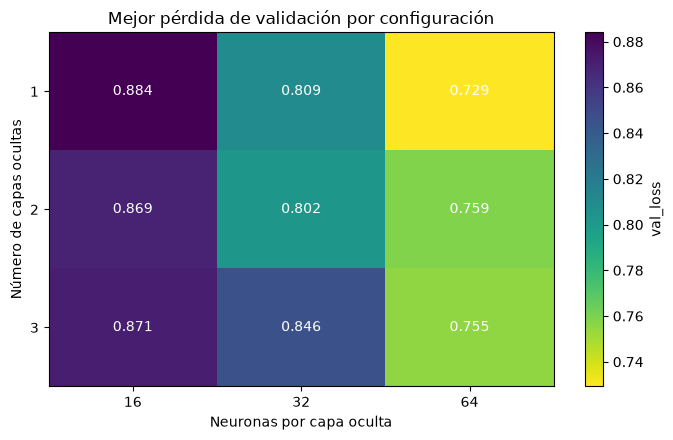

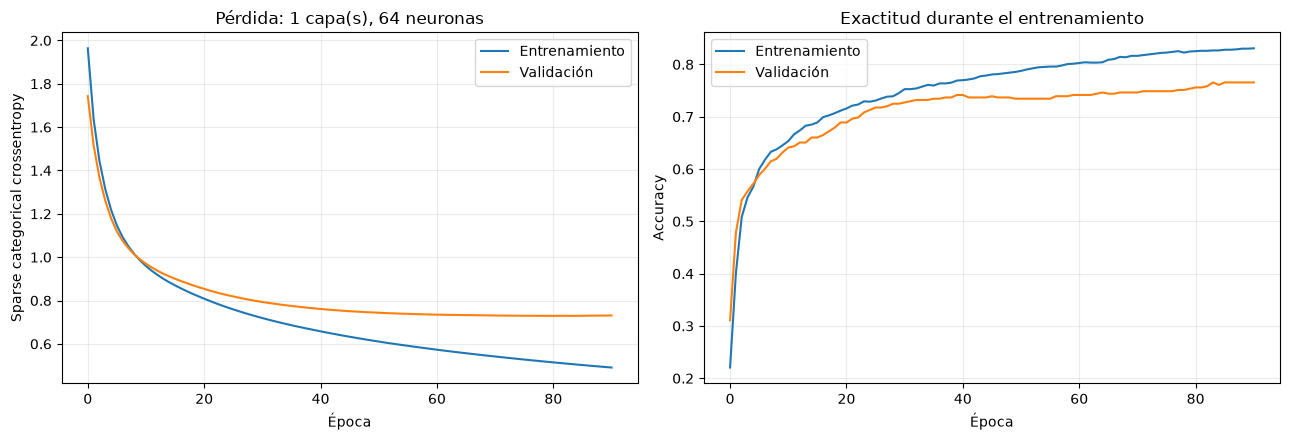

Reporte de clasificación en test:


,precision,recall,f1-score,support
Obesidad_Tipo_I,0.5641,0.6286,0.5946,35.0000
Obesidad_Tipo_II,0.8387,0.8667,0.8525,30.0000
Obesidad_Tipo_III,1.0000,1.0000,1.0000,32.0000
Peso_Insuficiente,0.6875,0.8148,0.7458,27.0000
Peso_Normal,0.6154,0.2857,0.3902,28.0000
Sobrepeso_Nivel_I,0.6129,0.6786,0.6441,28.0000
Sobrepeso_Nivel_II,0.5806,0.6207,0.6000,29.0000
accuracy,0.7033,0.7033,0.7033,0.7033
macro avg,0.6999,0.6993,0.6896,209.0000
weighted avg,0.7019,0.7033,0.6932,209.0000


Accuracy test: 0.7033
Balanced accuracy test: 0.6993
F1 macro test: 0.6896


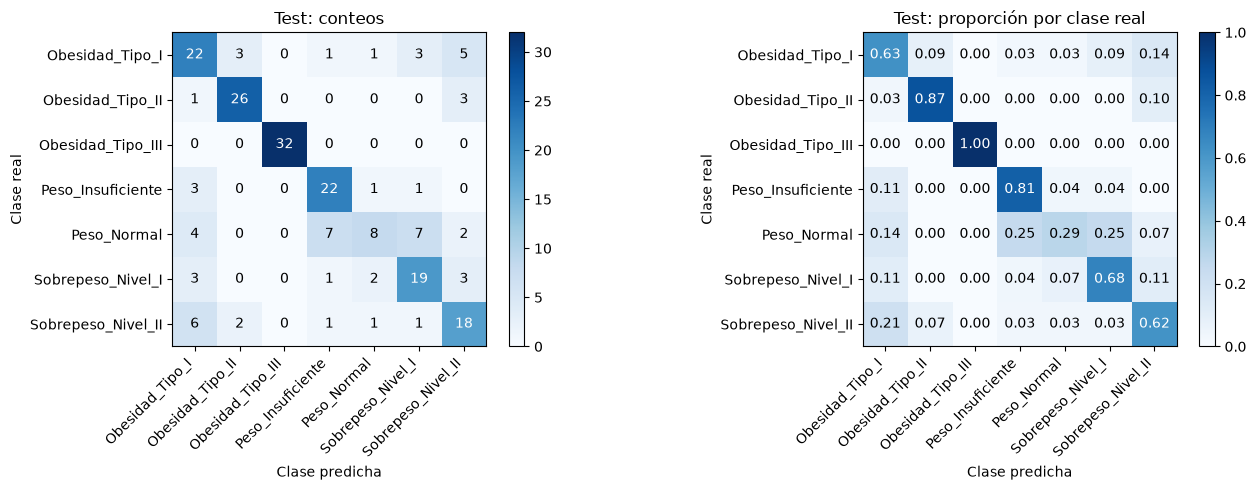

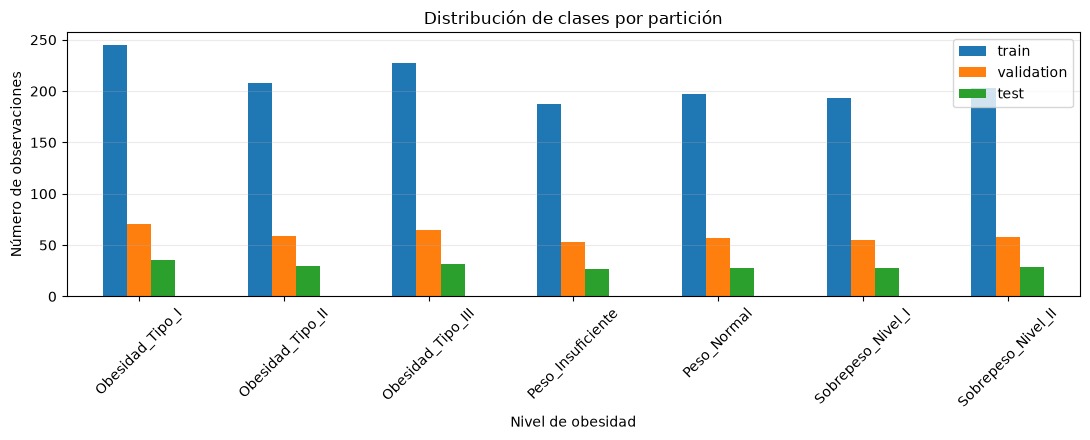

Resumen para las conclusiones:
- Mejor época según val_loss: 81 de 91.
- Brecha de accuracy (train - validation): 0.0653.
- Brecha de loss (validation - train): 0.2383.
- Clase con menor recall en test: Peso_Normal.


In [17]:
# Celda 13: Comparación reproducible, evaluación en test y visualizaciones
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# Se vuelve a registrar la búsqueda para conservar el resultado de cada arquitectura.
# Esto no usa el conjunto de test y permite construir la tabla comparativa.
grid_results = []
grid_models = {}
grid_histories = {}

for layers in hidden_layers_options:
    for neurons in neurons_options:
        config_name = f"{layers} capa(s), {neurons} neuronas"
        candidate = build_model(layers, neurons, input_dim, output_dim, lr=0.001)
        candidate_stop = EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        )
        candidate_history = candidate.fit(
            X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            epochs=300,
            batch_size=32,
            callbacks=[candidate_stop],
            verbose=0
        )
        history_dict = candidate_history.history
        best_epoch = int(np.argmin(history_dict['val_loss'])) + 1
        best_loss = float(np.min(history_dict['val_loss']))
        best_val_accuracy = float(np.max(history_dict['val_accuracy']))
        final_val_accuracy = float(candidate.evaluate(X_val_scaled, y_val, verbose=0)[1])

        grid_results.append({
            'capas_ocultas': layers,
            'neuronas_por_capa': neurons,
            'mejor_val_loss': best_loss,
            'mejor_val_accuracy': best_val_accuracy,
            'accuracy_val_pesos_finales': final_val_accuracy,
            'epoca_mejor_val_loss': best_epoch,
            'epocas_ejecutadas': len(history_dict['loss'])
        })
        grid_models[(layers, neurons)] = candidate
        grid_histories[(layers, neurons)] = history_dict

grid_results_df = pd.DataFrame(grid_results).sort_values(
    'mejor_val_loss'
).reset_index(drop=True)
final_config = (
    int(grid_results_df.loc[0, 'capas_ocultas']),
    int(grid_results_df.loc[0, 'neuronas_por_capa'])
)
final_model = grid_models[final_config]
final_history = grid_histories[final_config]

print('Comparación de las 9 configuraciones:')
display(grid_results_df.round(4))
print(f"Configuración seleccionada por menor val_loss: {final_config[0]} capa(s), {final_config[1]} neuronas")

# Comparación visual de la pérdida de validación por arquitectura.
loss_pivot = grid_results_df.pivot(
    index='capas_ocultas', columns='neuronas_por_capa', values='mejor_val_loss'
)
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(loss_pivot.values, cmap='viridis_r', aspect='auto')
ax.set_xticks(range(len(loss_pivot.columns)), loss_pivot.columns)
ax.set_yticks(range(len(loss_pivot.index)), loss_pivot.index)
ax.set_xlabel('Neuronas por capa oculta')
ax.set_ylabel('Número de capas ocultas')
ax.set_title('Mejor pérdida de validación por configuración')
for row in range(loss_pivot.shape[0]):
    for col in range(loss_pivot.shape[1]):
        ax.text(col, row, f'{loss_pivot.iloc[row, col]:.3f}', ha='center', va='center', color='white')
fig.colorbar(im, ax=ax, label='val_loss')
fig.tight_layout()
plt.show()

# Curvas del modelo finalmente seleccionado.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(final_history['loss'], label='Entrenamiento')
axes[0].plot(final_history['val_loss'], label='Validación')
axes[0].set_title(f'Pérdida: {final_config[0]} capa(s), {final_config[1]} neuronas')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Sparse categorical crossentropy')
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].plot(final_history['accuracy'], label='Entrenamiento')
axes[1].plot(final_history['val_accuracy'], label='Validación')
axes[1].set_title('Exactitud durante el entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

# Evaluación única sobre test, reservado hasta este punto.
y_test_probs = final_model.predict(X_test_scaled, verbose=0)
y_test_pred = np.argmax(y_test_probs, axis=1)
test_report = classification_report(
    y_test, y_test_pred, target_names=class_names, output_dict=True, zero_division=0
)
test_report_df = pd.DataFrame(test_report).T
print('Reporte de clasificación en test:')
display(test_report_df.round(4))
print(f"Accuracy test: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Balanced accuracy test: {balanced_accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 macro test: {f1_score(y_test, y_test_pred, average='macro'):.4f}")

# Matrices de confusión absoluta y normalizada.
test_cm = confusion_matrix(y_test, y_test_pred)
test_cm_norm = confusion_matrix(y_test, y_test_pred, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, matrix, title, fmt in [
    (axes[0], test_cm, 'Test: conteos', 'd'),
    (axes[1], test_cm_norm, 'Test: proporción por clase real', '.2f')
]:
    image = ax.imshow(matrix, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Clase predicha')
    ax.set_ylabel('Clase real')
    ax.set_xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    ax.set_yticks(range(len(class_names)), class_names)
    threshold = matrix.max() / 2
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            value = format(matrix[row, col], fmt)
            ax.text(col, row, value, ha='center', va='center',
                    color='white' if matrix[row, col] > threshold else 'black')
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

# Distribución de clases en cada partición, útil para contextualizar las métricas.
partition_counts = pd.DataFrame({
    'train': pd.Series(y_train).value_counts().reindex(range(len(class_names)), fill_value=0).to_numpy(),
    'validation': pd.Series(y_val).value_counts().reindex(range(len(class_names)), fill_value=0).to_numpy(),
    'test': pd.Series(y_test).value_counts().reindex(range(len(class_names)), fill_value=0).to_numpy()
}, index=class_names)
partition_counts.plot(kind='bar', figsize=(11, 4.5), rot=45)
plt.title('Distribución de clases por partición')
plt.xlabel('Nivel de obesidad')
plt.ylabel('Número de observaciones')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# Resumen numérico para apoyar la interpretación escrita.
train_best_accuracy = max(final_history['accuracy'])
val_best_accuracy = max(final_history['val_accuracy'])
train_best_loss = min(final_history['loss'])
val_best_loss = min(final_history['val_loss'])
print('Resumen para las conclusiones:')
print(f'- Mejor época según val_loss: {int(np.argmin(final_history["val_loss"]) + 1)} de {len(final_history["loss"])}.')
print(f'- Brecha de accuracy (train - validation): {train_best_accuracy - val_best_accuracy:.4f}.')
print(f'- Brecha de loss (validation - train): {val_best_loss - train_best_loss:.4f}.')
print(f'- Clase con menor recall en test: {test_report_df.loc[class_names, "recall"].astype(float).idxmin()}.')


## Análisis de resultados y conclusiones

### Comparación de arquitecturas

La tabla y el mapa de calor muestran que la configuración seleccionada fue la red de **1 capa oculta y 64 neuronas**, con una mejor pérdida de validación de aproximadamente **0.729**. En general, aumentar el ancho de la red desde 16 hasta 64 neuronas mejoró el desempeño. Las redes con 16 neuronas presentaron las pérdidas de validación más altas, lo que indica una capacidad limitada para representar la relación entre las variables de hábitos y el nivel de obesidad.

La profundidad adicional no produjo una mejora sistemática: con 64 neuronas, la red de una capa obtuvo el mejor resultado de esta ejecución, mientras que las arquitecturas de dos y tres capas fueron competitivas, pero no superiores. Por ello, se prefiere la red más sencilla que alcanzó el menor `val_loss`, ya que ofrece buen desempeño con menor complejidad.

### Interpretación de validation

Las curvas muestran una disminución continua de la pérdida de entrenamiento y de validación durante las primeras épocas. La pérdida de validación alcanza su mínimo alrededor de la época 81 y después se estabiliza, mientras la pérdida de entrenamiento continúa descendiendo. Esto evidencia una señal moderada de sobreajuste al final del entrenamiento, mitigada por `EarlyStopping` y `restore_best_weights=True`.

La exactitud máxima de entrenamiento fue aproximadamente 0.83 y la de validación 0.76, con una brecha cercana a 0.07. La diferencia no es despreciable, pero tampoco indica un colapso del modelo; la red aprende patrones generalizables, aunque todavía memoriza parte de los datos de entrenamiento. La matriz de confusión de validation debe leerse por clase y no solo mediante accuracy, porque algunos niveles tienen más confusiones entre categorías vecinas de peso.

### Evaluación final en test

El conjunto de test se mantuvo separado durante la búsqueda y se utilizó únicamente después de seleccionar la arquitectura. En esta ejecución se obtuvo:

- `Accuracy`: **0.7033**.
- `Balanced accuracy`: **0.6993**.
- `F1 macro`: **0.6896**.

La cercanía entre accuracy y balanced accuracy indica que el resultado no está explicado únicamente por una clase mayoritaria. La clase `Obesidad_Tipo_III` se identificó perfectamente en test, mientras que `Obesidad_Tipo_II` y `Peso_Insuficiente` también tuvieron buen recall. La mayor dificultad estuvo en `Peso_Normal`, cuyo recall fue aproximadamente **0.29**; sus observaciones se confundieron principalmente con `Peso_Insuficiente` y `Sobrepeso_Nivel_I`. También hubo confusiones entre niveles consecutivos de sobrepeso y obesidad, lo cual es razonable porque sus patrones de hábitos pueden ser similares.

### Veredicto y recomendaciones

El modelo es **funcional y aceptable como línea base**, pero no debe interpretarse como una herramienta clínica autónoma. Su desempeño cercano al 70% en test permite identificar patrones útiles en los datos, aunque el F1 macro y el bajo recall de `Peso_Normal` muestran que el rendimiento no es homogéneo entre clases.

Para mejorar el resultado se recomienda:

1. Repetir la búsqueda con varias semillas y comparar media y desviación estándar, porque una sola partición puede favorecer o perjudicar algunas arquitecturas.
2. Probar `class_weight` o técnicas de balanceo para mejorar el recall de las clases con más errores.
3. Ajustar `dropout`, regularización L2 y la tasa de aprendizaje para reducir la brecha entre entrenamiento y validación.
4. Comparar el MLP con modelos de referencia para datos tabulares, como Random Forest, Gradient Boosting o XGBoost.
5. Mantener el conjunto de test reservado para la evaluación final y reportar siempre métricas por clase, no solo accuracy.

### Revisión de la primera parte

La primera parte está bien encaminada: diferencia variables nominales y ordinales, usa codificación apropiada, divide los datos de forma estratificada y ajusta el `StandardScaler` únicamente con entrenamiento antes de transformar validation y test. También implementa correctamente la salida `softmax`, la pérdida `sparse_categorical_crossentropy` y `EarlyStopping`.

Como mejora metodológica futura, sería preferible encapsular el preprocesamiento en un pipeline reproducible y fijar una estrategia explícita de semillas para cada configuración. Además, aunque el one-hot encoding no calcula parámetros estadísticos, puede construirse dentro de un flujo ajustado solo con train para hacer más estricta la separación entre entrenamiento y evaluación. No se modificó esta parte en esta entrega, tal como se solicitó.

### **Rúbrica**

| Criterio | Peso | Qué se evalúa |
|-|-|-|
| Preprocesamiento de datos | 15 % | Codificación adecuada de las variables categóricas, diferenciando entre nominales y ordinales escalamiento de las variables numéricas; y separación correcta de los conjuntos de entrenamiento, <br> validación y prueba, evitando fuga de información. |
| Implementación del MLP | 15 % | Arquitectura correctamente construida, con función de activación de salida y función de pérdida apropiadas para clasificación multiclase; código funcional y bien organizado. |
| Búsqueda de hiperparámetros | 25 % | Las 9 configuraciones están correctamente implementadas y entrenadas, early stopping está configurado con un valor de patience justificado. Los resultados se presentan de forma <br> clara mediante una tabla o gráfico comparativo. |
| Evaluación y métricas | 15 % | Uso de métricas apropiadas para clasificación multiclase, considerando posibles diferencias en el tamaño de las clases; evaluación final realizada correctamente sobre el conjunto de test.  |
| Interpretación y justificación | 20 % | Justificación de la arquitectura final con base en los resultados y las curvas de entrenamiento y validación; identificación de señales de sobreajuste o subajuste; conclusiones sobre el efecto <br> de la profundidad y el ancho de la red. |
| Calidad y reproducibilidad del notebook | 10 % | El notebook se ejecuta de principio a fin sin errores, está organizado en un orden lógico, no contiene código innecesario e incluye explicaciones breves en Markdown que guían la lectura. |